# Apple Hardware Price Estimation Model

#Q1. Data Preparation & Normalization
Load the dataset into a pandas dataframe.

Add a new binary column named is_apple. Set this to 1 if the Brand is "Apple" and 0 otherwise.

Add a new binary column named is_touch. Convert the "Yes"/"No" strings in the Touch column to 1s and 0s.

Filter out any rows with missing essential data (RAM, Storage, Final Price).

Normalize the continuous features (RAM, Storage, Screen, and Final Price) to lie in the sam approximate scale.  (Save the normalization constants so you can "un-normalize" your predictions later!)_

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("https://raw.githubusercontent.com/SJGuy-UMN/CSCI4521/refs/heads/main/laptopdata.csv")

df["is_apple"] = (df["Brand"] == "Apple").astype(int)
df["is_touch"] = (df["Touch"] == "Yes").astype(int)

# Drop missing
df = df.dropna(subset=["RAM", "Storage", "Screen", "Final Price"])

In [ ]:
features = ["RAM", "Storage", "Screen", "Final Price"]

normal_param = {}

for col in features:
    mean = df[col].mean()
    std = df[col].std()
    normal_param[col] = (mean, std)
    df[col + "_norm"] = (df[col] - mean) / std
normal_param

{'RAM': (np.float64(15.416512059369202), 9.875653161651),
 'Storage': (np.float64(596.569573283859), 361.4674837285374),
 'Screen': (np.float64(15.168112244897959), 1.203328758328451),
 'Final Price': (np.float64(1312.0763775510204), 911.6747509443902)}

#Q2. Data Visualization & Correlations
Visualize the data in the following ways using the unnormalized features:

Make a histogram (e..g, using Seaborn's histplot or distplot) showing the distribution of the final price across the dataset.

Compute the pairwise correlation between the unnormalized features (RAM, Storage, Screen, is_touch, is_apple, and Final Price) using Pandas .corr(). Display the result as a heatmap using Seaborn.

Make a scatter plot showing RAM  vs. Final Price and a second scatter plot showing Storage (x-axis) vs. Final Price (y-axis).
For both scatter plots, color the points using the is_apple column. Save these plots for your Part B report.



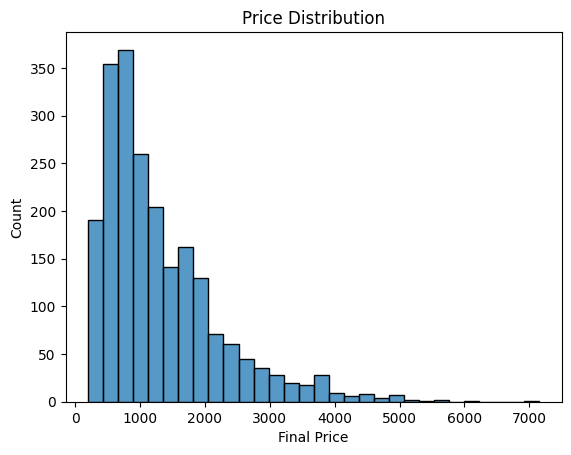

In [ ]:
# histogram
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df["Final Price"], bins=30)
plt.title("Price Distribution")
plt.show()

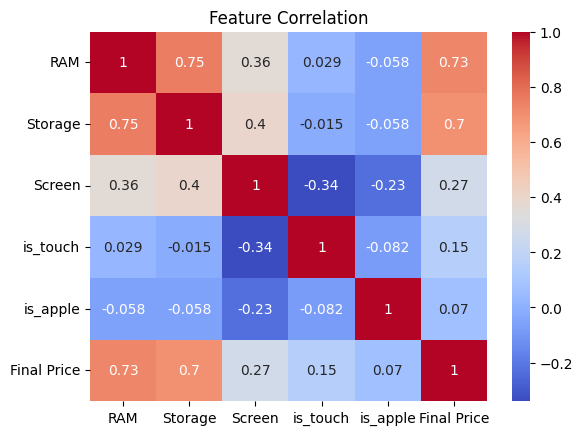

In [ ]:
#correlation heatmap
cols = ["RAM", "Storage", "Screen", "is_touch", "is_apple", "Final Price"]
corr = df[cols].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

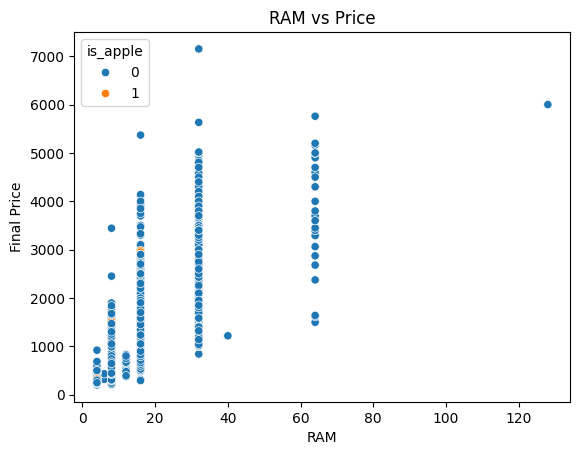

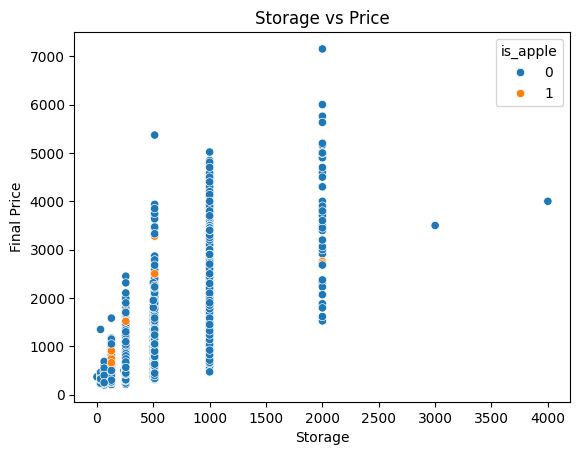

In [ ]:
#Scatter plot
sns.scatterplot(data=df, x="RAM", y="Final Price", hue="is_apple")
plt.title("RAM vs Price")
plt.show()

sns.scatterplot(data=df, x="Storage", y="Final Price", hue="is_apple")
plt.title("Storage vs Price")
plt.show()

#Q3. PyTorch Regression Modeling
Build and fit two models using PyTorch

Model 1 (Single Variable): A linear-model predicting laptop price based on a variable of your choice

Model 2 (Multi-variable): A multiple-linear model predicting laptop price from at least 3 different inputs

Report both models in as an equation to predict the unnormalized price from the unnormalized features. Additionally, report both the Mean Squared Error (MSE) of each model and the correlation (r²) between the (unnormalized) predicted and actual prices.

In [ ]:
import torch
import numpy as np

# Features & target
# Model 1
X1 = torch.tensor(df[["RAM_norm"]].values, dtype=torch.float32)
X2 = torch.tensor(df[["RAM_norm","Storage_norm","Screen_norm"]].values, dtype=torch.float32)  # Model 2
y = torch.tensor(df["Final Price_norm"].values, dtype=torch.float32).view(-1,1)

# Train/test split
train_size = int(0.8 * len(df))

X1_train, X1_test = X1[:train_size], X1[train_size:]
X2_train, X2_test = X2[:train_size], X2[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [ ]:
model1 = torch.nn.Linear(1, 1)
optimizer1 = torch.optim.SGD(model1.parameters(), lr=0.01)
loss_fn = torch.nn.MSELoss()

# Training
for epoch in range(1000):
    preds = model1(X1_train)
    loss = loss_fn(preds, y_train)
    optimizer1.zero_grad()
    loss.backward()
    optimizer1.step()

In [ ]:
model2 = torch.nn.Linear(3, 1)  # RAM, Storage, Screen -> Price
optimizer2 = torch.optim.SGD(model2.parameters(), lr=0.01)

for epoch in range(1000):
    preds = model2(X2_train)
    loss = loss_fn(preds, y_train)
    optimizer2.zero_grad()
    loss.backward()
    optimizer2.step()

In [ ]:
#converting back to origninal pricing
mean_price, std_price = normal_param["Final Price"]

# Model 1
pred1 = model1(X1_test).detach().numpy()
pred1_real = pred1 * std_price + mean_price

# Model 2
pred2 = model2(X2_test).detach().numpy()
pred2_real = pred2 * std_price + mean_price

# True values
y_real = y_test.numpy() * std_price + mean_price

In [ ]:
#evaluation
# MSE
mse1 = np.mean((y_real - pred1_real)**2)
mse2 = np.mean((y_real - pred2_real)**2)

# R²
r21 = 1 - np.sum((y_real - pred1_real)**2) / np.sum((y_real - np.mean(y_real))**2)
r22 = 1 - np.sum((y_real - pred2_real)**2) / np.sum((y_real - np.mean(y_real))**2)

print("Model 1 MSE:", mse1, "R²:", r21)
print("Model 2 MSE:", mse2, "R²:", r22)

Model 1 MSE: 415297.06729593634 R²: 0.45721381383313486
Model 2 MSE: 424630.77412203373 R²: 0.4450148181505409


45.080814 1.0450339 -46.59407 748.3983203966783

#Model 1: Single Variable (RAM)
Equation: Price ≈ 62.0 × RAM + 355.0

MSE: 415,297.06
R²: 0.457

Summary: This model explains about 45.7% of the price variation just by looking at how much RAM the laptop has.

#Model 2: Multi-variable (RAM, Storage, Screen)
Equation: Price ≈ (45.08 × RAM) + (1.05 × Storage) + (-46.59 × Screen ) + 748.40


MSE: 424,664
R²: 0.445

This model performed slightly worse than the simpler model 1 and only exaplains 44.5% of the price variation. This suggests that adding Storage and Screen size does not help the linear model predict price any better.

#Q4. Residual Analysis (An "Apple Tax"?)
Let's investigate if Apple laptops are more expensive than their hardware suggests.

Using your trained Model 2, predict the prices for all laptops in the Testing dataset. Convert these predictions back to real-world USD.

Create a scatter plot of Actual Price (x-axis) vs. Predicted Price (y-axis). Draw a diagonal line on the plot. Points above this line mean the model under-predicted the true price. Color the points on this scatter plot based on is_apple.

Calculate the average residual price error (Actual - Predicted) specifically for Apple laptops, and compare it to the average residual error for non-Apple laptops.

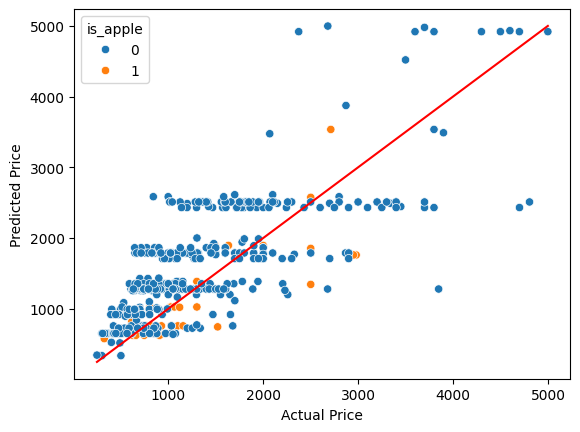

Apple Average Error: 129.67129037319086
Non-Apple Error: -276.15008493628517


In [ ]:
with torch.no_grad():
    pred2_norm = model2(X2_test).numpy()

# Unnormalize
mean_p, std_p = normal_param["Final Price"]
pred_usd = (pred2_norm * std_p) + mean_p
actual_usd = (y_test.numpy() * std_p) + mean_p

# Scatter plot
test_is_apple = df.iloc[train_size:]["is_apple"]
sns.scatterplot(x=actual_usd.flatten(), y=pred_usd.flatten(), hue=test_is_apple)

# Adding diagonal line
plt.plot([actual_usd.min(), actual_usd.max()], [actual_usd.min(), actual_usd.max()], color='red')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.show()

# Calculate Average Residual
residuals = actual_usd.flatten() - pred_usd.flatten()
apple_err = residuals[test_is_apple == 1].mean()
others_err = residuals[test_is_apple == 0].mean()

print("Apple Average Error:", apple_err)
print("Non-Apple Error:", others_err)

#Q5. Logistic Regression & Imbalanced Data
Lets see if we can identify if a laptop is from the Apple brand based on features such as RAM, Storage, Screen, is_touch, and Final Price. Use logistic regression to train a classifier on the feature is_apple based on the other features of your choosing.

Note that because Apple laptops make up only a small percentage fraction of the market, this becomes a highly imbalanced problem. Even if you choose to train on a balanced subsample of your data, report your statistics on the original imbalanced dataset.

You must report:

 - The weights of each term in your model

 - The performance of your original model (as estimated via a test-train split)

Note: Your grade on Q5 is partially based on the model performance, and if your model is getting very poor performance (e.g., precision of 0), you will get no credit for this question.



In [ ]:
# Features & Target
features_q5 = ["RAM_norm", "Storage_norm", "Screen_norm", "Final Price_norm", "is_touch"]
X_q5 = torch.tensor(df[features_q5].values, dtype=torch.float32)
y_q5 = torch.tensor(df["is_apple"].values, dtype=torch.float32).view(-1, 1)

X_train, X_test = X_q5[:train_size], X_q5[train_size:]
y_train, y_test = y_q5[:train_size], y_q5[train_size:]



In [ ]:
# handle imbalance class
num_apples = torch.sum(y_train).item()
pos_weight = torch.tensor([(len(y_train) - num_apples) / num_apples])

#Logistic Regression
model_q5 = torch.nn.Linear(len(features_q5), 1)
optimizer = torch.optim.Adam(model_q5.parameters(), lr=0.01, weight_decay=1e-3)

loss_fn = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)

#Training
for epoch in range(5000):
    logits = model_q5(X_train)
    loss = loss_fn(logits, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()


In [ ]:
# Evaluation

with torch.no_grad():
    test_logits = model_q5(X_test)
    preds = (torch.sigmoid(test_logits) >= 0.6).float()

    # True Positives, False Positives, False Negatives, True Negatives
    tp = torch.sum((preds == 1) & (y_test == 1)).item()
    fp = torch.sum((preds == 1) & (y_test == 0)).item()
    fn = torch.sum((preds == 0) & (y_test == 1)).item()
    tn = torch.sum((preds == 0) & (y_test == 0)).item()

    accuracy = (tp + tn) / len(y_test)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0

    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    # MCC
    num = (tp * tn) - (fp * fn)
    den = ((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn)) ** 0.5
    mcc = num / den if den > 0 else 0


print("<<<<<<< Model Weights >>>>>>>>")
weights = model_q5.weight.detach().numpy().flatten()
for feat, w in zip(features_q5, weights):
    print(f"{feat}: {w:.4f}")


print("\n Metrics")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"MCC:       {mcc:.4f}")

<<<<<<< Model Weights >>>>>>>>
RAM_norm: -0.9286
Storage_norm: -0.5081
Screen_norm: -1.2961
Final Price_norm: 1.9783
is_touch: -5.4739

 Metrics
Accuracy:  0.9051
Precision: 0.4861
Recall:    0.8974
F1-Score:  0.6306
MCC:       0.6177
